Keras also supports a simpler interface to save both the model weights and model architecture together into a single `H5` file. Saving the model in this way includes everything we need to know about the model, including:
- Model weights.
- Model architecture.
- Model compilation details (loss and metrics). 
- Model optimizer state.
This means that we can load and use the model directly, without having to re-compile it as we did in the examples above. This is the preferred way for saving and loading your Keras model.

### 1. How to Save a Keras Model 

In [5]:
# Version 2
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import ModelCheckpoint
import pandas as pd

dataset = pd.read_csv('diabetes.csv')
dataset.columns = ['NTP', 'PGC','DBP','TSFT','2hSI','BMI','DPF','Age','OnDiab']

X = dataset.drop("OnDiab", axis=1)
Y = dataset["OnDiab"]

model = Sequential([
    Dense(12, input_dim=8, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

filepath = "weights-improvement-{epoch:02d}-{val_accuracy:.2f}.weights.h5"
checkpoint = ModelCheckpoint(
    filepath=filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=True,   # <-- key change
    mode='max'
)

model.fit(
    X, Y,
    validation_split=0.33,
    epochs=150,
    batch_size=10,
    callbacks=[checkpoint],
    verbose=0
)

# evaluate the model
scores = model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))
# save model and architecture to single file
model.save("model.h5")
print("Saved model to disk")

/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 1: val_accuracy improved from -inf to 0.64567, saving model to weights-improvement-01-0.65.weights.h5

Epoch 2: val_accuracy did not improve from 0.64567

Epoch 3: val_accuracy did not improve from 0.64567

Epoch 4: val_accuracy did not improve from 0.64567

Epoch 5: val_accuracy did not improve from 0.64567

Epoch 6: val_accuracy did not improve from 0.64567

Epoch 7: val_accuracy did not improve from 0.64567

Epoch 8: val_accuracy did not improve from 0.64567

Epoch 9: val_accuracy did not improve from 0.64567

Epoch 10: val_accuracy did not improve from 0.64567

Epoch 11: val_accuracy did not improve from 0.64567

Epoch 12: val_accuracy did not improve from 0.64567

Epoch 13: val_accuracy did not improve from 0.64567

Epoch 14: val_accuracy did not improve from 0.64567

Epoch 15: val_accuracy improved from 0.64567 to 0.64961, saving model to weights-improvement-15-0.65.weights.h5

Epoch 16: val_accuracy did not improve from 0.64961

Epoch 17: val_accuracy improved from 0.6496

compile_metrics: 72.49%
Saved model to disk


### 2. How to Load a Keras Model
Your saved model can then be loaded later by calling the `load_model()` function and passing the filename. The function returns the model with the same architecture and weights.

In [6]:
model.save("model.diab.keras")

from keras.models import load_model
model = load_model('model.diab.keras')

/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [10]:
# Version 2
from keras.models import Sequential
from keras.layers import Dense

model = Sequential([
    Dense(12, input_dim=8, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# summarize model.
model.summary()

# Load file with best accuracy
import os
import re

files = [f for f in os.listdir() if f.startswith("weights-improvement")]

def extract_val_acc(filename):
    # matches the last floating number before .weights.h5
    return float(re.search(r"-(\d+\.\d+)\.weights\.h5$", filename).group(1))

best_file = max(files, key=extract_val_acc)

print("Best checkpoint:", best_file)

model.load_weights(best_file)

# evaluate the model
score = model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

Best checkpoint: weights-improvement-146-0.78.weights.h5
compile_metrics: 76.66%


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### 3. Checkpoint Neural Network Model Improvements

Application checkpointing is a fault tolerance technique for long running processes. It is an approach where a snapshot of the state of the system is taken in case of system failure. If there is a problem, not all is lost. The checkpoint may be used directly, or used as the starting point for a new run, picking up where it left off. When training deep learning models, the checkpoint captures the weights of the model. These weights can be used to make predictions as-is, or used as the basis for ongoing training.

The Keras library provides a checkpointing capability by a callback API. The `ModelCheckpoint` callback class allows you to define where to checkpoint the model weights, how the file should be named and under what circumstances to make a checkpoint of the model. The API allows you to specify which metric to monitor, such as loss or accuracy on the training or validation dataset. You can specify whether to look for an improvement in maximizing or minimizing the score. Finally, the filename that you use to store the weights can include variables like the epoch number or metric. The `ModelCheckpoint` instance can then be passed to the training process when calling the `fit()` function on the model.

##### Arguments
- **filepath:** string, path to save the model file.
- **monitor:** quantity to monitor.
- **verbose:** verbosity mode, 0 or 1.
- **save_best_only:** if save_best_only=True, the latest best model according to the quantity monitored will not be overwritten.
- **save_weights_only:** if True, then only the model’s weights will be saved (model.save_weights(filepath)), else the full model is saved (model.save(filepath)).
- **mode:** one of {auto, min, max}. If save_best_only=True, the decision to overwrite the current save file is made based on either the maximization or the minimization of the monitored quantity. For val_acc, this should be max, for val_loss this should be min, etc. In auto mode, the direction is automatically inferred from the name of the monitored quantity.
- **period:** Interval (number of epochs) between checkpoints.

A good use of checkpointing is to output the model weights each time an improvement is observed during training. Checkpointing is set up to save the network weights only when there is an improvement in classification accuracy on the validation dataset `(monitor=’val accuracy’ and mode=’max’)`. The weights are stored in a file that includes the score in the filename `weights-improvement-epoch-val accuracy=.2f.hdf5`.

In [11]:
# Checkpoint the weights when validation accuracy improves
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import ModelCheckpoint
import pandas as pd


# load pima indians dataset
dataset = pd.read_csv('diabetes.csv')
dataset.columns = ['NTP', 'PGC','DBP','TSFT','2hSI','BMI','DPF','Age','OnDiab']


# split into input (X) and output (Y) variables
X = dataset.drop("OnDiab",axis=1)
Y = dataset["OnDiab"]

# create model
model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


# checkpoint
filepath = "weights-improvement-{epoch:02d}-{val_accuracy:.2f}.weights.h5"

checkpoint = ModelCheckpoint(
    filepath=filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=True,   # <-- REQUIRED
    mode='max'
)

callbacks_list = [checkpoint]



# Fit the model
model.fit(X, Y, validation_split=0.33, epochs=150, batch_size=10, callbacks=callbacks_list,
verbose=0)

/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 1: val_accuracy improved from -inf to 0.54331, saving model to weights-improvement-01-0.54.weights.h5

Epoch 2: val_accuracy improved from 0.54331 to 0.56693, saving model to weights-improvement-02-0.57.weights.h5

Epoch 3: val_accuracy did not improve from 0.56693

Epoch 4: val_accuracy improved from 0.56693 to 0.59449, saving model to weights-improvement-04-0.59.weights.h5

Epoch 5: val_accuracy improved from 0.59449 to 0.62205, saving model to weights-improvement-05-0.62.weights.h5

Epoch 6: val_accuracy improved from 0.62205 to 0.63386, saving model to weights-improvement-06-0.63.weights.h5

Epoch 7: val_accuracy did not improve from 0.63386

Epoch 8: val_accuracy did not improve from 0.63386

Epoch 9: val_accuracy did not improve from 0.63386

Epoch 10: val_accuracy improved from 0.63386 to 0.66929, saving model to weights-improvement-10-0.67.weights.h5

Epoch 11: val_accuracy did not improve from 0.66929

Epoch 12: val_accuracy did not improve from 0.66929

Epoch 13: val_a

### 4. Checkpoint Best Neural Network Model Only
A simpler checkpoint strategy is to save the model weights to the same file, if and only if the validation accuracy improves. This can be done easily using the same code from above and changing the output filename to be fixed (not include score or epoch information). In this case, model weights are written to the file `weights.best.hdf5` only if the classification accuracy of the model on the validation dataset improves over the best seen so far.

In [14]:
# Checkpoint the weights for best model on validation accuracy
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import ModelCheckpoint
import pandas as pd


# load pima indians dataset
dataset = pd.read_csv('diabetes.csv')
dataset.columns = ['NTP', 'PGC','DBP','TSFT','2hSI','BMI','DPF','Age','OnDiab']


# split into input (X) and output (Y) variables
X = dataset.drop("OnDiab",axis=1)
Y = dataset["OnDiab"]


# create model
model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


# checkpoint
filepath = "weights.best.weights.h5"
#filepath="weights.best.hdf5"
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1,
save_best_only=True, mode='max')
callbacks_list = [checkpoint]


# Fit the model
model.fit(X, Y, validation_split=0.33, epochs=150, batch_size=10, callbacks=callbacks_list,
verbose=0)

/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 1: val_accuracy improved from -inf to 0.55512, saving model to weights.best.weights.h5



Epoch 2: val_accuracy improved from 0.55512 to 0.57087, saving model to weights.best.weights.h5



Epoch 3: val_accuracy improved from 0.57087 to 0.61024, saving model to weights.best.weights.h5



Epoch 4: val_accuracy did not improve from 0.61024

Epoch 5: val_accuracy did not improve from 0.61024

Epoch 6: val_accuracy did not improve from 0.61024

Epoch 7: val_accuracy improved from 0.61024 to 0.61811, saving model to weights.best.weights.h5


...


Epoch 20: val_accuracy did not improve from 0.69291

Epoch 21: val_accuracy did not improve from 0.69291

Epoch 22: val_accuracy improved from 0.69291 to 0.70079, saving model to weights.best.weights.h5



Epoch 23: val_accuracy did not improve from 0.70079

Epoch 24: val_accuracy did not improve from 0.70079

Epoch 25: val_accuracy improved from 0.70079 to 0.70866, saving model to weights.best.weights.h5



Epoch 26: val_accuracy did not improve from 0.70866

Epoch 27: val_accuracy did not improve from 0.70866

Epoch 28: val_accuracy did not improve from 0.70866

Epoch 29: val_accuracy improved from 0.70866 to 0.72835, saving model to weights.best.weights.h5



Epoch 30: val_accuracy did not improve from 0.72835

Epoch 31: val_accuracy did not improve from 0.72835

Epoch 32: val_accuracy improved from 0.72835 to 0.73228, saving model to weights.best.weights.h5



Epoch 33: val_accuracy did not improve from 0.73228

Epoch 34: val_accuracy did not improve from 0.73228

Epoch 35: val_accuracy did not improve from 0.73228

Epoch 36: val_accuracy did not improve from 0.73228

Epoch 37: val_accuracy did not improve from 0.73228

Epoch 38: val_accuracy did not improve from 0.73228

Epoch 39: val_accuracy did not improve from 0.73228

Epoch 40: val_accuracy did not improve from 0.73228

Epoch 41: val_accuracy did not improve from 0.73228

Epoch 42: val_accuracy did not improve from 0.73228

Epoch 43: val_accuracy did not improve from 0.73228

Epoch 44: val_accuracy did not improve from 0.73228

Epoch 45: val_accuracy did not improve from 0.73228

Epoch 46: val_accuracy did not improve from 0.73228

Epoch 47: val_accuracy did not improve from 0.73228

Epoch 48: val_accuracy did not improve from 0.73228

Epoch 49: val_accuracy did not improve from 0.73228

Epoch 50: val_accuracy did not improve from 0.73228

Epoch 51: val_accuracy did not improve from 0

### 5. Loading a Saved Neural Network Model

Now that you have seen how to checkpoint your deep learning models during training, you need to review how to load and use a checkpointed model. The checkpoint only includes the model weights. It assumes you know the network structure. In the example below, the model structure is known and the best weights are loaded from the previous experiment, stored in the working directory in the `weights.best.hdf5` file. The model is then used to make predictions on the entire dataset.

In [19]:
from keras.models import Sequential
from keras.layers import Dense
import pandas as pd
import os, re

# ---- pick best weights file (.weights.h5) ----
files = [f for f in os.listdir() if f.endswith(".weights.h5")]
if not files:
    raise FileNotFoundError("No .weights.h5 files found in the current directory.")

def extract_val_acc(fn):
    m = re.search(r"-(\d+\.\d+)\.weights\.h5$", fn)
    return float(m.group(1)) if m else -1

best_file = max(files, key=extract_val_acc)
print("Loading:", best_file)

# ---- rebuild the SAME model architecture ----
model = Sequential([
    Dense(12, input_dim=8, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# (Optional but helpful) compile before/after is fine; compile is needed for evaluate()
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# ---- load weights ----
model.load_weights(best_file)
print("Created model and loaded weights from file")

# ---- load data & evaluate ----
dataset = pd.read_csv('diabetes.csv')
dataset.columns = ['NTP', 'PGC','DBP','TSFT','2hSI','BMI','DPF','Age','OnDiab']

X = dataset.drop("OnDiab", axis=1)
Y = dataset["OnDiab"]

scores = model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1] * 100))


Loading: weights-improvement-146-0.78.weights.h5
Created model and loaded weights from file
compile_metrics: 76.66%


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [3]:
#OLD 
# How to load and use weights from a checkpoint
from keras.models import Sequential
from keras.layers import Dense
import pandas as pd


# create model
model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


# load weights
model.load_weights("weights.best.hdf5")


# Compile model (required to make predictions)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print("Created model and loaded weights from file")


# load pima indians dataset
dataset = pd.read_csv('diabetes.csv')
dataset.columns = ['NTP', 'PGC','DBP','TSFT','2hSI','BMI','DPF','Age','OnDiab']


# split into input (X) and output (Y) variables
X = dataset.drop("OnDiab",axis=1)
Y = dataset["OnDiab"]


# estimate accuracy on whole dataset using loaded weights
scores = model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))     
                       

Created model and loaded weights from file
accuracy: 73.27%


### 6. Visualize Model Training History in Keras


In [20]:
# Visualize training history
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt
# load pima indians dataset
dataset = pd.read_csv('diabetes.csv')
dataset.columns = ['NTP', 'PGC','DBP','TSFT','2hSI','BMI','DPF','Age','OnDiab']

# split into input (X) and output (Y) variables
X = dataset.drop("OnDiab",axis=1)
Y = dataset["OnDiab"]
# define model
model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Fit the model
history = model.fit(X, Y, validation_split=0.33, epochs=500, batch_size=20, verbose=0)
# list all data in history
print(history.history.keys())


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


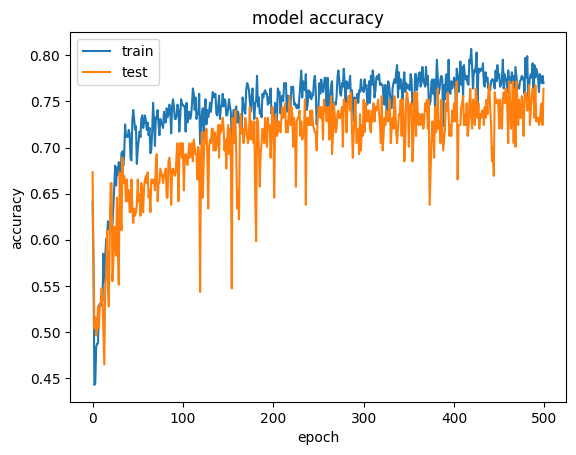

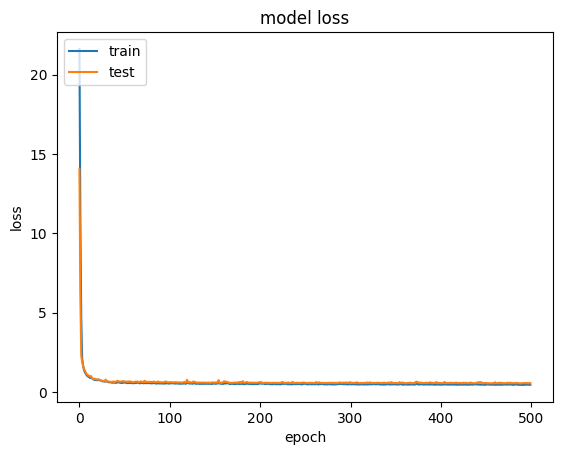

In [21]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [4]:
X.shape

(767, 8)